In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

from icdmappings import Mapper

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report



In [2]:
# %% Carregar datasets já divididos
train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

In [3]:

target = "TriageGrade"
mapper = Mapper()

val_df['Block'] =mapper.map(val_df['ChiefComplaint'], source='icd10', target='block')

y_test = val_df[target]


In [4]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    # Gera o relatório como dicionário para extrair métricas por classe
    report = classification_report(y, preds, output_dict=True, zero_division=0)

    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, average="weighted", zero_division=0),
        "recall": recall_score(y, preds, average="weighted", zero_division=0),
        "f1": f1_score(y, preds, average="weighted", zero_division=0),
        # Extrai o recall da classe 5 (ajusta para 5 ou '5' conforme o teu dataset)
        "recall_class_5": report.get('5', report.get(5, {})).get('recall', 0),
        "preds": preds
    }


In [5]:
def plot_cm(y, preds, name):
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [6]:
def plot_cm_normalized(y, preds, name):
    # O parâmetro normalize='true' divide os valores pelo total de cada classe real (linhas)
    cm = confusion_matrix(y, preds, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues")
    plt.title(f"Matriz de Confusão Normalizada - {name}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()


In [7]:
from sklearn.preprocessing import label_binarize

def plot_pr_curve_class_5(y_test, probas, model_name, class_label=5):
    # Binarizar para a classe específica
    classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=classes)

    # Encontrar o índice da classe 5
    class_idx = list(classes).index(class_label)

    # Extrair probabilidades apenas para a classe 5
    precision, recall, _ = precision_recall_curve(y_bin[:, class_idx], probas[:, class_idx])

    plt.plot(recall, precision, label=f"{model_name} (Classe {class_label})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curva Precision-Recall - Classe 5")
    plt.legend()


In [8]:
def plot_threshold_analysis(y_test, probas, model_name, class_label=5):
    classes = np.unique(y_test)
    class_idx = list(classes).index(class_label)
    probs_class_5 = probas[:, class_idx]
    y_true_binary = (y_test == class_label).astype(int)

    thresholds = np.linspace(0, 1, 100)
    recalls = []
    precisions = []

    for th in thresholds:
        th_preds = (probs_class_5 >= th).astype(int)
        recalls.append(recall_score(y_true_binary, th_preds, zero_division=0))
        precisions.append(precision_score(y_true_binary, th_preds, zero_division=0))

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, recalls, label="Recall (Classe 5)")
    plt.plot(thresholds, precisions, label="Precision (Classe 5)")
    plt.axvline(0.5, color="red", linestyle="--", label="Threshold Padrão (0.5)")
    plt.xlabel("Limiar de Decisão (Threshold)")
    plt.ylabel("Score")
    plt.title(f"Análise de Limiar - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [12]:
def recall_per_class(y_true, y_pred, model_name):
    # Gera o relatório como dicionário para acesso programático [1, 2]
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    data = []
    # np.unique identifica todas as classes reais presentes no dataset [3, 4]
    for label in np.unique(y_true).astype(str):
        if label in report:
            data.append({
                "model": model_name,
                "class": label,
                "recall": report[label]['recall'] # Extrai o recall individual da classe [1]
            })
    return data


In [9]:
def multiclass_auc(y, probas):
    classes = np.unique(y)
    y_bin = label_binarize(y, classes=classes)

    return roc_auc_score(
        y_bin,
        probas,
        average="macro",
        multi_class="ovr"
    )

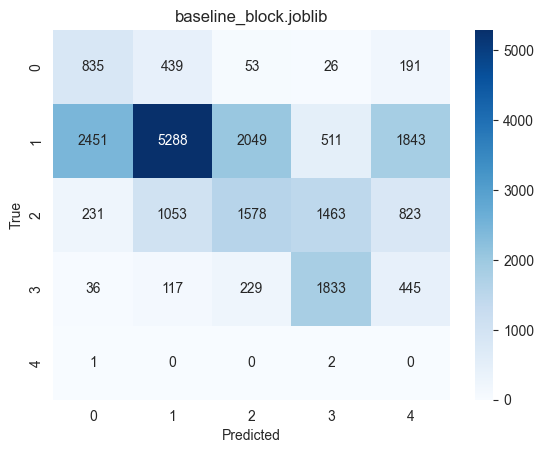

Relatório para baseline_block.joblib:
              precision    recall  f1-score   support

           1       0.23      0.54      0.33      1544
           2       0.77      0.44      0.56     12142
           3       0.40      0.31      0.35      5148
           4       0.48      0.69      0.56      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.44     21497
   macro avg       0.38      0.39      0.36     21497
weighted avg       0.61      0.44      0.49     21497



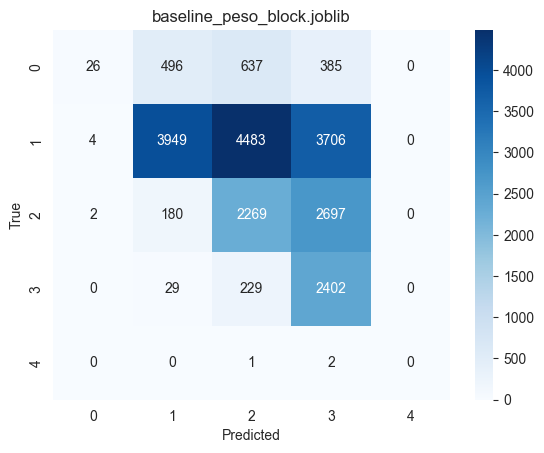

Relatório para baseline_peso_block.joblib:
              precision    recall  f1-score   support

           1       0.81      0.02      0.03      1544
           2       0.85      0.33      0.47     12142
           3       0.30      0.44      0.36      5148
           4       0.26      0.90      0.41      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.40     21497
   macro avg       0.44      0.34      0.25     21497
weighted avg       0.64      0.40      0.40     21497



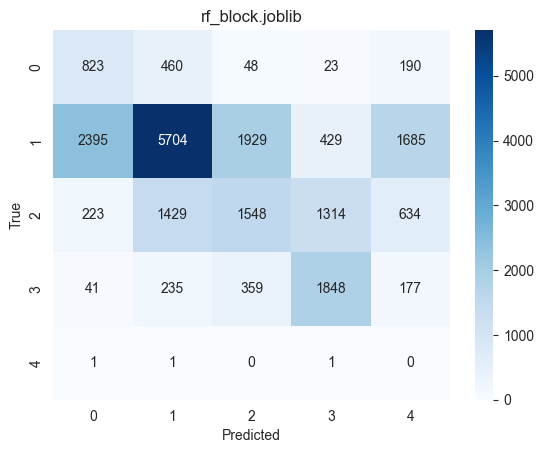

Relatório para rf_block.joblib:
              precision    recall  f1-score   support

           1       0.24      0.53      0.33      1544
           2       0.73      0.47      0.57     12142
           3       0.40      0.30      0.34      5148
           4       0.51      0.69      0.59      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.46     21497
   macro avg       0.37      0.40      0.37     21497
weighted avg       0.59      0.46      0.50     21497



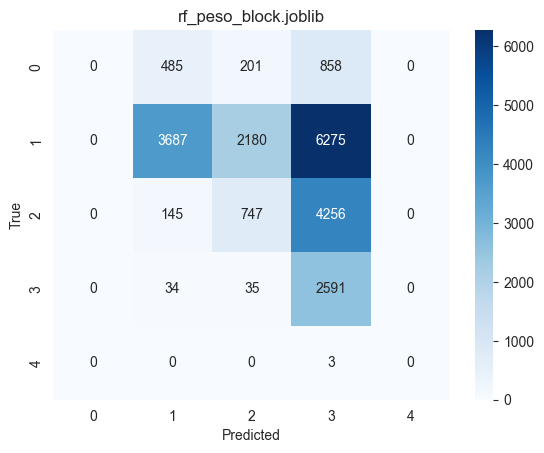

Relatório para rf_peso_block.joblib:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      1544
           2       0.85      0.30      0.45     12142
           3       0.24      0.15      0.18      5148
           4       0.19      0.97      0.31      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.33     21497
   macro avg       0.25      0.28      0.19     21497
weighted avg       0.56      0.33      0.33     21497



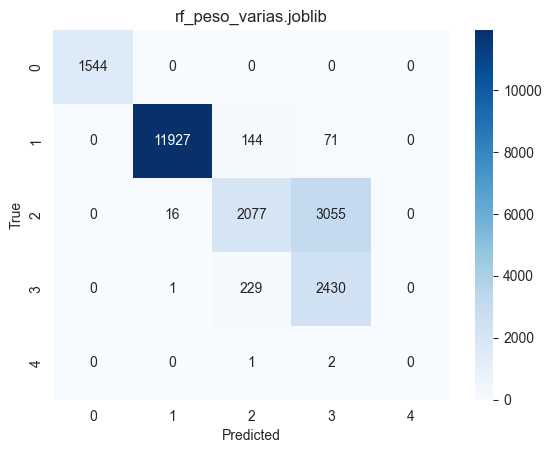

Relatório para rf_peso_varias.joblib:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1544
           2       1.00      0.98      0.99     12142
           3       0.85      0.40      0.55      5148
           4       0.44      0.91      0.59      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.84     21497
   macro avg       0.66      0.66      0.63     21497
weighted avg       0.89      0.84      0.84     21497



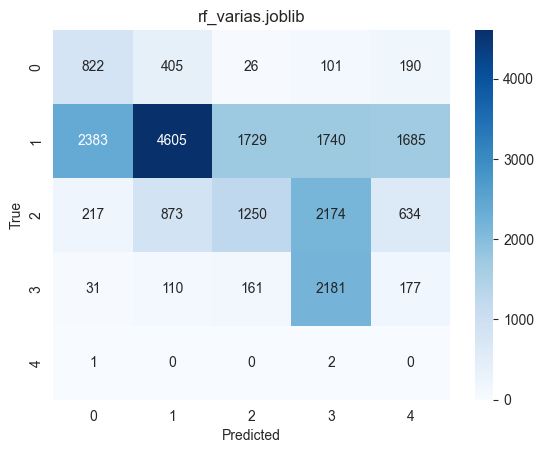

Relatório para rf_varias.joblib:
              precision    recall  f1-score   support

           1       0.24      0.53      0.33      1544
           2       0.77      0.38      0.51     12142
           3       0.39      0.24      0.30      5148
           4       0.35      0.82      0.49      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.41     21497
   macro avg       0.35      0.39      0.33     21497
weighted avg       0.59      0.41      0.44     21497



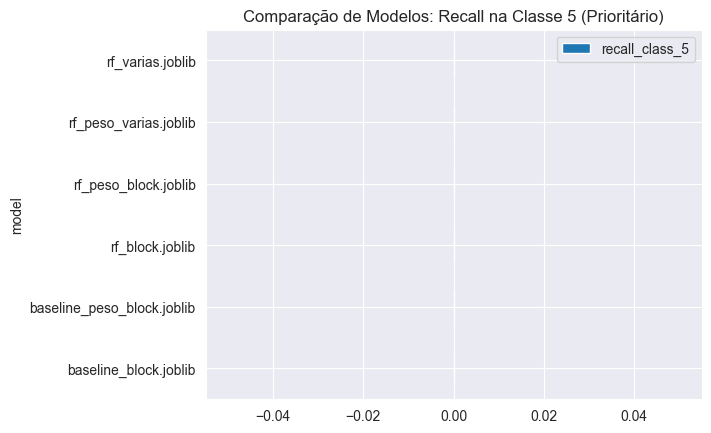

In [13]:
models_to_test = [
    "models/models/baseline_block.joblib",
    "models/models/baseline_peso_block.joblib",
    #"models/models/gb_varias.joblib",
    "models/models/rf_block.joblib",
    "models/models/rf_peso_block.joblib",
    "models/models/rf_peso_varias.joblib",
    "models/models/rf_varias.joblib",
]
auc_results = []
results =[]
recall_per_class_data = [] # Corrigido: Inicialização necessária [1]

for path in models_to_test:
    data = joblib.load(path)
    model = data["model"]
    features = data["features"]
    name = path.split("/")[-1]

    # Seleção de features simplificada
    X_test_model = val_df[features] # Corrigido: Removida redundância [1]

    # Obtenção de predições e probabilidades
    preds = model.predict(X_test_model)
    probas = model.predict_proba(X_test_model)

    # Cálculo das métricas
    auc = multiclass_auc(y_test, probas)
    out = evaluate_model(model, X_test_model, y_test)

    # Relatório detalhado para extração de recall por classe
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    # Coleta de recall individual por classe para o gráfico de barras
    for label in np.unique(y_test).astype(str):
        if label in report:
            recall_per_class_data.append({
                "model": name,
                "class": f"Classe {label}",
                "recall": report[label]['recall'] # Extrai o recall individual [7]
            })

    # Armazenamento dos resultados gerais
    results.append({
        "model": name,
        "accuracy": out["accuracy"],
        "precision": out["precision"],
        "recall": out["recall"],
        "f1": out["f1"],
        "recall_class_5": out["recall_class_5"] # Métrica prioritária [7]
    })

    auc_results.append({
        "model": name,
        "auc_macro_ovr": auc
    })

    # Visualização imediata por modelo
    plot_cm(y_test, preds, name) # Usando preds já calculados
    print(f"Relatório para {name}:")
    print(classification_report(y_test, preds, zero_division=0))

# Criação dos DataFrames finais após o loop
df_recalls_all = pd.DataFrame(recall_per_class_data)
df_comp = pd.DataFrame(results)
df_comp.sort_values("recall_class_5", ascending=False).plot(x="model", y="recall_class_5", kind="barh")
plt.title("Comparação de Modelos: Recall na Classe 5 (Prioritário)")
plt.show()





In [32]:
df_results = pd.DataFrame(results)
df_results.sort_values("recall_class_5", ascending=False)



,model,accuracy,precision,recall,f1,recall_class_5
4,modelo_logreg_multi.joblib,0.870866,0.911916,0.870866,0.886588,0.666667
5,modelo_logreg_multi_new.joblib,0.865842,0.909816,0.865842,0.883513,0.333333
6,modelo_logreg_multi_new_weight.joblib,0.865842,0.909816,0.865842,0.883513,0.333333
0,baseline.joblib,0.676792,0.661281,0.676792,0.633254,0.000000
1,decision_tree.joblib,0.775922,0.801260,0.775922,0.784592,0.000000
3,decision_tree_new_weight.joblib,0.894311,0.899095,0.894311,0.896489,0.000000
2,decision_tree_new.joblib,0.894311,0.899095,0.894311,0.896489,0.000000
7,random_forest.joblib,0.750802,0.820044,0.750802,0.772326,0.000000
8,random_forest_new.joblib,0.887147,0.894606,0.887147,0.889536,0.000000
9,random_forest_new_weight.joblib,0.887147,0.894606,0.887147,0.889536,0.000000
